# 04 — Analysis: Metrics and Plots

Combine central and federated k-means results, compute final metrics,
and generate comparison plots.

**What this notebook does:**
1. Load central k-means results from notebook 02.
2. Load federated k-means results from notebook 03 (if available).
3. Compute ARI, MCC, accuracy for all (method x target) combinations.
4. Generate ARI bar charts, PCA comparison plots, multi-dataset summary.

**Prerequisites:** Run notebooks 01 and 02. Notebook 03 is optional.

## Imports

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import sys

import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
sys.path.append(str(REPO_ROOT / "evaluation_utils"))
from learning_evaluation_plot_helpers import PUB_RC, METHOD_META, METHODS_ORDER, \
    DATASET_LABELS, TARGET_LABELS, extract_method_key, plot_ari_grouped, plot_pca_dataset, plot_ari_scatter

from evaluation_utils.real_datasets_utils import (
    dataset_configs,
    evaluate_metrics,
    load_fed_metadata,
    save_metrics_tables,
    load_feature_matrix,
)

def display_styled_or_plain(df, make_styler):
    try:
        display(make_styler(df))
    except AttributeError as exc:
        if "requires jinja2" not in str(exc):
            raise
        display(df)

## Configuration

In [2]:
DATASETS = [
    "ecoli",
    "ovarian_cancer",
    "ccRCC_proteomics", "quartet_multiomics"]
OUTPUT_ROOT = NOTEBOOK_DIR

# Style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

## Load Results and Compute Metrics

In [3]:
all_metrics = []
dataset_data = {}  # store loaded data for PCA plots
configs = dataset_configs(REPO_ROOT)

for ds_name in DATASETS:
    ds_dir = OUTPUT_ROOT / ds_name
    run_dir = ds_dir / "kmeans_res" / "runs"

    # Load central results (from notebook 02)
    central_path = run_dir / "1_metadata_cntrl_kmeans_res.tsv"
    if not central_path.exists():
        print(f"[{ds_name}] Central results not found — run notebook 02 first.")
        continue
    central_res = pd.read_csv(central_path, sep="\t")

    # Load federated results (from notebook 03, optional)
    before_fed = load_fed_metadata(run_dir / "1_metadata_before_fedclusters.tsv")
    after_fed = load_fed_metadata(run_dir / "1_metadata_after_fedclusters.tsv")

    k_condition = int(central_res['condition'].nunique())
    k_batch = int(central_res['lab'].nunique())

    print(f"\n{'='*60}")
    print(f"{ds_name}: k_condition={k_condition}, k_batch={k_batch}")
    if before_fed is not None:
        print(f"  Federated before: {before_fed.shape[0]} samples")
    if after_fed is not None:
        print(f"  Federated after: {after_fed.shape[0]} samples")

    metrics = evaluate_metrics(
        dataset_name=ds_name,
        central_res=central_res,
        before_fed_res=before_fed,
        after_fed_res=after_fed,
        k_condition=k_condition,
        k_batch=k_batch,
    )
    all_metrics.append(metrics)

    # Also store matrices for PCA
    prepared_dir = ds_dir / "prepared"
    dataset_data[ds_name] = {
        'before': load_feature_matrix(prepared_dir / "before_matrix.tsv"),
        'corrected': load_feature_matrix(prepared_dir / "corrected_matrix.tsv"),
        'metadata': central_res,
        'before_fed': before_fed,
        'after_fed': after_fed,
        'k_condition': k_condition,
        'k_batch': k_batch,
    }

combined_metrics = pd.concat(all_metrics, ignore_index=True)
save_metrics_tables(combined_metrics, OUTPUT_ROOT)
print(f"\nCombined metrics saved to {OUTPUT_ROOT}")


ecoli: k_condition=2, k_batch=5

ovarian_cancer: k_condition=2, k_batch=6

ccRCC_proteomics: k_condition=2, k_batch=3

quartet_multiomics: k_condition=4, k_batch=3

Combined metrics saved to /home/jk/featurecloudALL/apps/fedRBE/evaluation_clusterization_after_correction/real_datasets


## Metrics Table

In [4]:
# Display full metrics table with ARI heatmap coloring.
display_cols = ["Dataset", "Target", "K", "Method", "ARI", "N"]
metrics_table = combined_metrics[display_cols].copy()
display_styled_or_plain(
    metrics_table,
    lambda df: df.style.format({"ARI": "{:.3f}"}).background_gradient(
        subset=["ARI"], cmap="RdYlGn", vmin=-0.1, vmax=1
    ),
)

,Dataset,Target,K,Method,ARI,N
0,ecoli,condition,2,ecoli_condition_BC_Cntrl_2cls,-0.005,118
1,ecoli,condition,2,ecoli_condition_AC_Cntrl_2cls,1.000,118
2,ecoli,batch,5,ecoli_batch_BC_Cntrl_5cls,1.000,118
3,ecoli,batch,5,ecoli_batch_AC_Cntrl_5cls,-0.008,118
4,ovarian_cancer,condition,2,ovarian_cancer_condition_BC_Cntrl_2cls,0.108,332
5,ovarian_cancer,condition,2,ovarian_cancer_condition_AC_Cntrl_2cls,0.140,332
6,ovarian_cancer,batch,6,ovarian_cancer_batch_BC_Cntrl_6cls,0.801,332
7,ovarian_cancer,batch,6,ovarian_cancer_batch_AC_Cntrl_6cls,0.068,332
8,ccRCC_proteomics,condition,2,ccRCC_proteomics_condition_BC_Cntrl_2cls,-0.000,887
9,ccRCC_proteomics,condition,2,ccRCC_proteomics_condition_AC_Cntrl_2cls,0.869,887


## Plot Style

Publication-quality constants, colour palette, and helper functions used by all figures below.

## ARI Comparison

All datasets side-by-side; Condition (left) and Batch (right) targets.
Dashed vertical lines separate dataset groups. Hatching = federated.

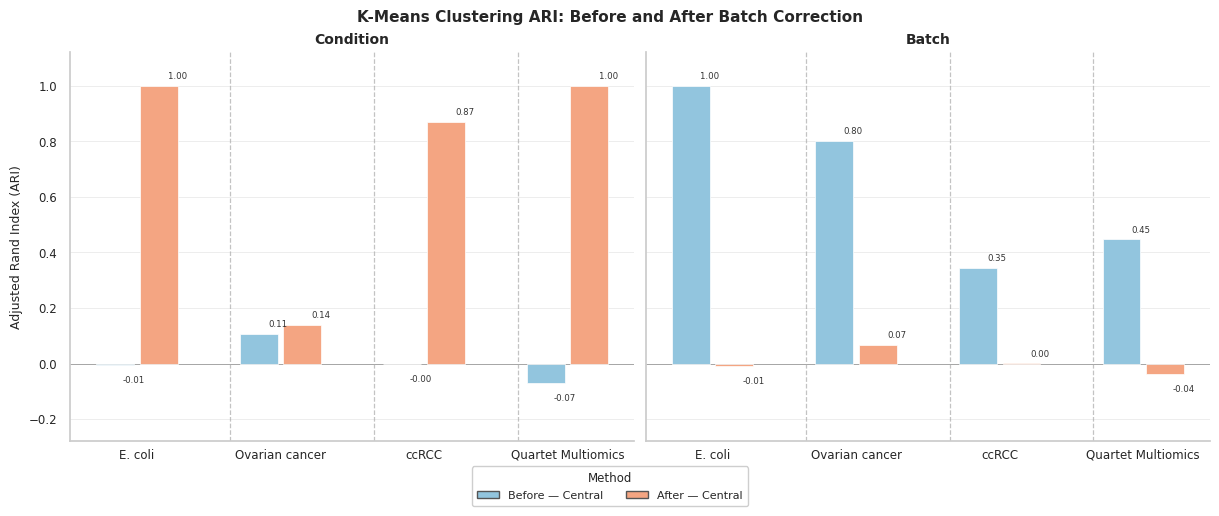

In [5]:
fig_ari = plot_ari_grouped(combined_metrics, DATASETS)

## PCA: Before vs. After Correction

2 × 2 grid per dataset: rows = Before / After correction; columns = Condition / Batch true labels.

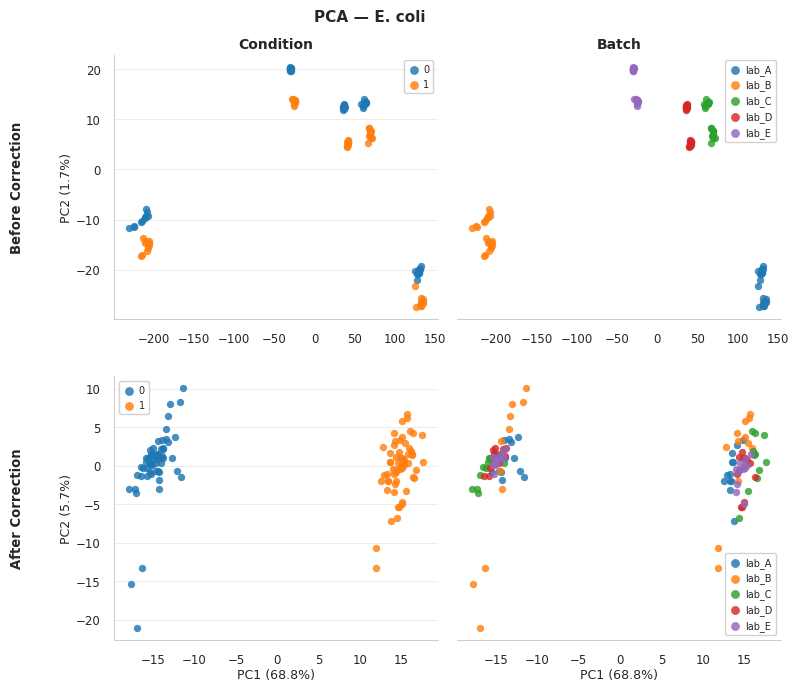

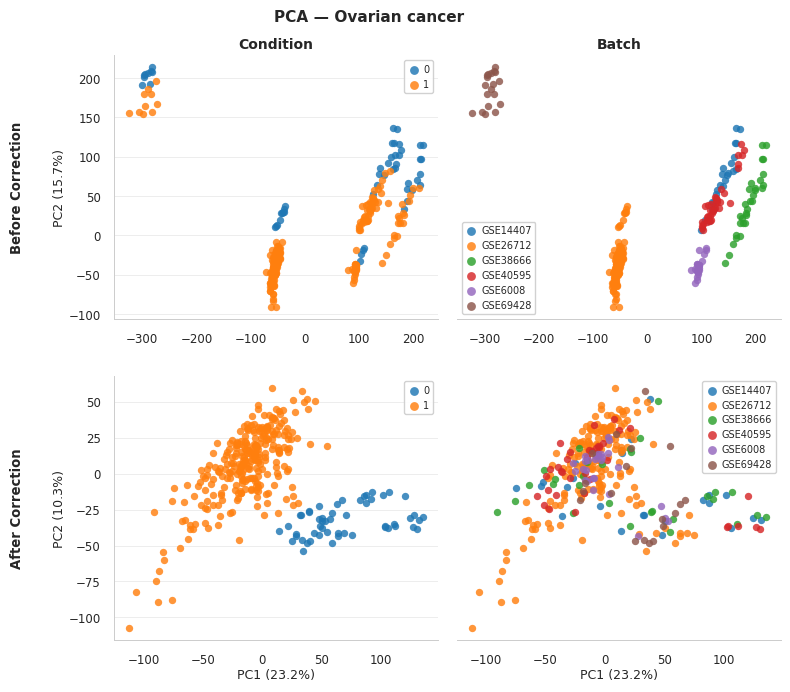

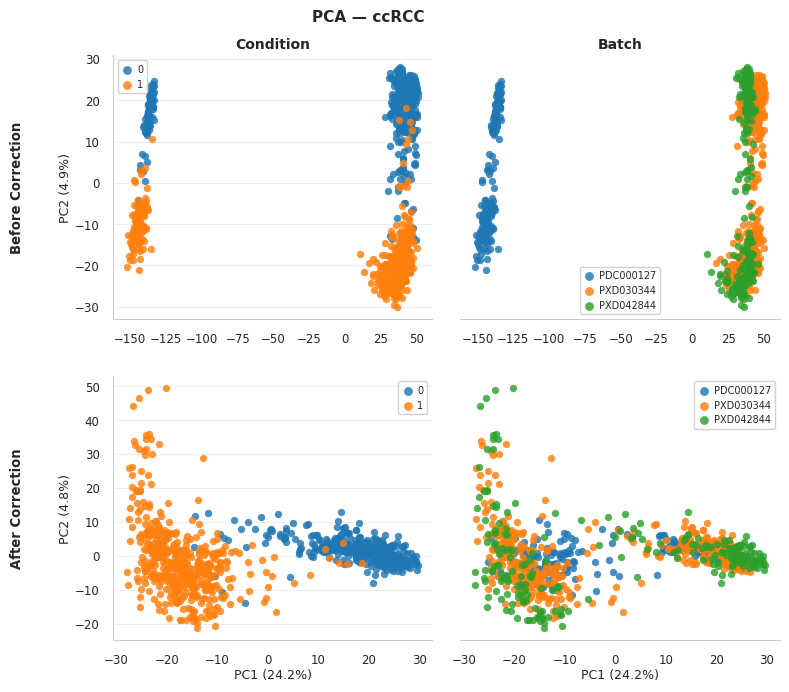

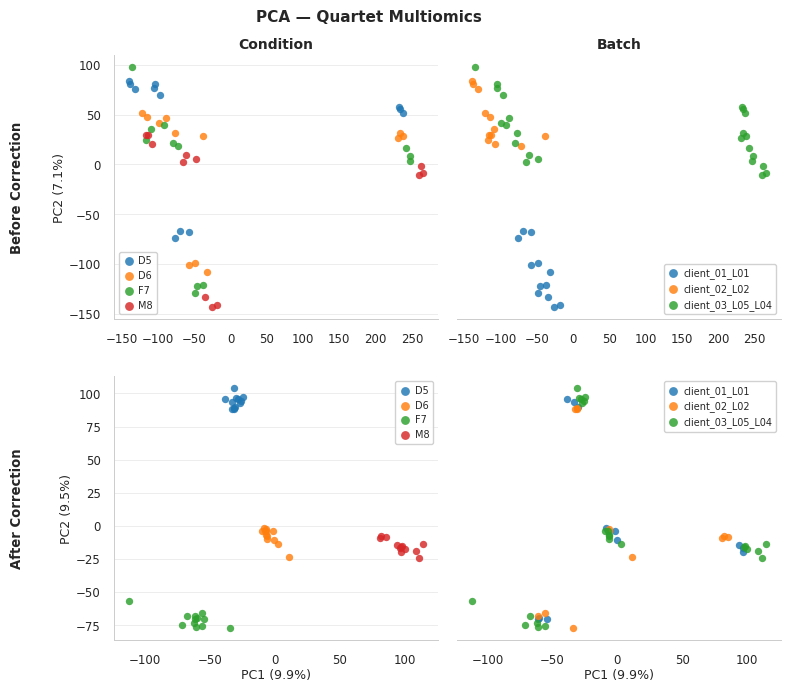

In [6]:
import sys
sys.path.append(str(REPO_ROOT / "evaluation_utils"))
from learning_evaluation_plot_helpers import plot_pca_dataset


for ds_name, data in dataset_data.items():
    plot_pca_dataset(ds_name, data)

## ARI: Before vs. After Correction (Scatter)

Each point = one (dataset × target) pair. Points above the diagonal indicate
improvement after batch correction. Color = target; marker = dataset.

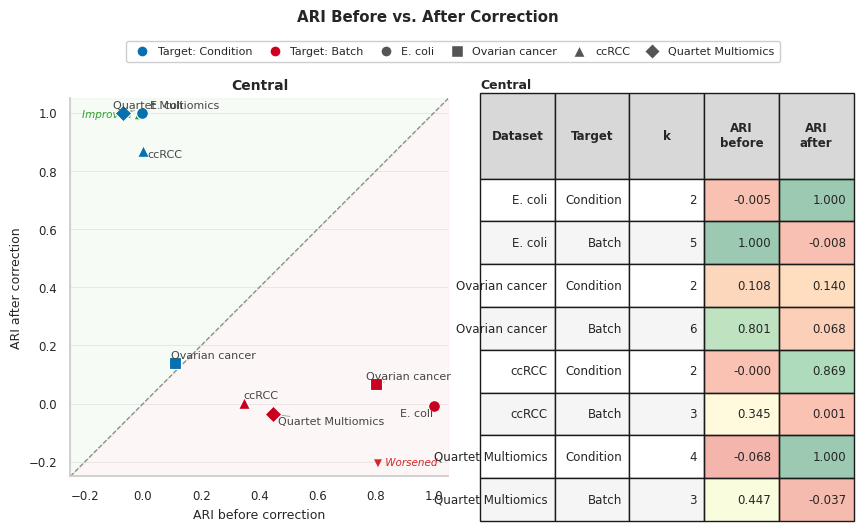

In [7]:
fig_scatter = plot_ari_scatter(combined_metrics, DATASETS)


**Figure. ARI before vs. after batch correction for Central and Federated correction and following k-means clustering.**
Each point represents one dataset × target combination. The x-axis shows the Adjusted Rand Index (ARI) before correction and the y-axis shows ARI after correction. Points above the diagonal (dashed line) indicate improvement in clustering quality after batch correction; points below indicate worsening. Point color denotes the clustering target (blue = Condition, red = Batch); marker shape denotes the dataset. Summary tables on the right report exact ARI values for each combination. Results are shown separately for Central (top) and Federated (bottom) batch correction and clustering.

## Summary Table

ARI before, after, and Δ for all dataset × target × method combinations.
Green Δ = improvement; red Δ = worsening.

In [8]:
df_summ = combined_metrics.copy()
df_summ["MethodKey"] = df_summ["Method"].apply(extract_method_key)

summary_rows = []
for ds_name in DATASETS:
    ds_df = df_summ[df_summ["Dataset"] == ds_name]
    for target in ds_df["Target"].unique():
        tdf = ds_df[ds_df["Target"] == target]
        for variant, bk, ak in [
            ("Central",   "BC_Cntrl", "AC_Cntrl"),
            ("Federated", "BC_Fed",   "AC_Fed"),
        ]:
            brow = tdf[tdf["MethodKey"] == bk]
            arow = tdf[tdf["MethodKey"] == ak]
            if brow.empty or arow.empty:
                continue
            ari_b = float(brow["ARI"].iloc[0])
            ari_a = float(arow["ARI"].iloc[0])
            delta = ari_a - ari_b
            summary_rows.append({
                "Dataset":      DATASET_LABELS.get(ds_name, ds_name).replace("\n", " "),
                "Target":       TARGET_LABELS[target],
                "K":            int(brow["K"].iloc[0]),
                "Variant":      variant,
                "ARI (before)": round(ari_b, 4),
                "ARI (after)":  round(ari_a, 4),
                "Δ ARI":        round(delta, 4),
                "Result":       "✓" if delta > 0.01 else ("~" if abs(delta) <= 0.01 else "✗"),
            })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    display_styled_or_plain(
        summary_df,
        lambda df: (
            df.style
            .format({
                "ARI (before)": "{:.4f}",
                "ARI (after)":  "{:.4f}",
                "Δ ARI":        "{:+.4f}",
            })
            .background_gradient(
                subset=["ARI (before)", "ARI (after)"],
                cmap="RdYlGn", vmin=0, vmax=1,
            )
            .background_gradient(
                subset=["Δ ARI"],
                cmap="RdYlGn", vmin=-0.3, vmax=0.3,
            )
            .map(
                lambda v: (
                    "color: #2ca02c; font-weight: bold" if v == "✓"
                    else ("color: #d62728; font-weight: bold" if v == "✗" else "color: #888888")
                ),
                subset=["Result"],
            )
            .set_table_styles([
                {"selector": "thead th",
                 "props": [("font-weight", "bold"), ("font-size", "10px"),
                           ("background-color", "#f5f5f5")]},
                {"selector": "td",
                 "props": [("font-size", "10px"), ("padding", "4px 8px")]},
            ])
        ),
    )
else:
    print("No summary data available.")

,Dataset,Target,K,Variant,ARI (before),ARI (after),Δ ARI,Result
0,E. coli,Condition,2,Central,-0.0051,1.0000,+1.0051,✓
1,E. coli,Batch,5,Central,1.0000,-0.0084,-1.0084,✗
2,Ovarian cancer,Condition,2,Central,0.1082,0.1398,+0.0317,✓
3,Ovarian cancer,Batch,6,Central,0.8012,0.0676,-0.7337,✗
4,ccRCC,Condition,2,Central,-0.0003,0.8691,+0.8694,✓
5,ccRCC,Batch,3,Central,0.3454,0.0008,-0.3446,✗
6,Quartet Multiomics,Condition,4,Central,-0.0682,1.0000,+1.0682,✓
7,Quartet Multiomics,Batch,3,Central,0.4471,-0.0368,-0.4838,✗


## Dataset Description

Per-center breakdown of samples and features for the multi-batch ecoli and ccRCC E. coli datasets used in this analysis.


### Multi-batch MS-based E. coli dataset

MS-based ecoli, 4-condition E. coli dataset (D5, D6, F7, M8 growth conditions); each center contributed samples acquired with one or two MS methods (DDA and/or DIA).

| Center | MS methods (batches) | Total features | Total samples | D5 | D6 | F7 | M8 |
|--------|----------------------|---------------|:-------------:|:--:|:--:|:--:|:--:|
| APT | DDA + DIA | 3407 | 24 | 6 | 6 | 6 | 6 |
| BGI | DIA | 3407 | 12 | 3 | 3 | 3 | 3 |
| FDU | DDA + DIA | 3407 | 24 | 6 | 6 | 6 | 6 |
| NVG | DDA | 3407 | 12 | 3 | 3 | 3 | 3 |

### ccRCC MS-based E. coli dataset

MS-based ecoli, clear cell Renal Cell Carcinoma (ccRCC) dataset (Normal vs. Tumor); each center is one public ecoli study.

| Center | Total features | Total samples | Normal | Tumor |
|--------|---------------|:-------------:|:------:|:-----:|
| PDC000127 | 9964 | 194 | 84 | 110 |
| PXD030344 | 12548 | 464 | 232 | 232 |
| PXD042844 | 7655 | 229 | 114 | 115 |

### Multi-omics quartet dataset

Three modalities (Transcriptomics, Proteomics, Metabolomics) measured on the
same Quartet donors (D5, D6, F7, M8). Used in joint mode: features from all
three modalities are stacked into one row-zscored, equal-block-weighted
matrix before k-means.

| Client | Donors | Replicates | Transcriptomics | Proteomics | Metabolomics | Joint features |
|--------|--------|:---------:|:--------------:|:----------:|:------------:|:--------------:|
| client_01_L01      | D5/D6/F7/M8 | 16 | 26907 | 2539 | 71 | 29517 |
| client_02_L02      | D5/D6/F7/M8 | 16 | 26907 | 2539 | 71 | 29517 |
| client_03_L05_L04  | D5/D6/F7/M8 | 16 | 26907 | 2539 | 71 | 29517 |
